<a href="https://colab.research.google.com/github/josdank/Fundamentos-de-IA/blob/Pruebas/Examen_bim1_FIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
# Integrantes
print(" Josué Guerra\n Christian Marquez\n Luis Ramos")

 Josué Guerra
 Christian Marquez
 Luis Ramos


In [29]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

# Carga y Exploración de Datos
url = "https://raw.githubusercontent.com/josdank/Fundamentos-de-IA/Pruebas/dataClientesGimnasio.csv"
df = pd.read_csv(url)
print(df.head())
print(df.info())

# Eliminación de columnas irrelevantes
columnas_a_eliminar = ['ID', 'Sexo']  # Eliminamos columnas que no aportan al análisis
df_clean = df.drop(columns=columnas_a_eliminar)
print("Columnas después de limpieza:", df_clean.columns)


   ID  Edad Sexo  Altura  Peso  FrecuenciaSemanal  Antiguedad
0   1    24    M     175    72                  4          12
1   2    31    F     160    60                  3           6
2   3    27    M     180    80                  5          24
3   4    35    F     165    68                  2           3
4   5    22    M     178    75                  6          18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 60 non-null     int64 
 1   Edad               60 non-null     int64 
 2   Sexo               60 non-null     object
 3   Altura             60 non-null     int64 
 4   Peso               60 non-null     int64 
 5   FrecuenciaSemanal  60 non-null     int64 
 6   Antiguedad         60 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 3.4+ KB
None
Columnas después de limpieza: Index(['Edad', 'Al

In [32]:
# Preprocesamiento - Normalización
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

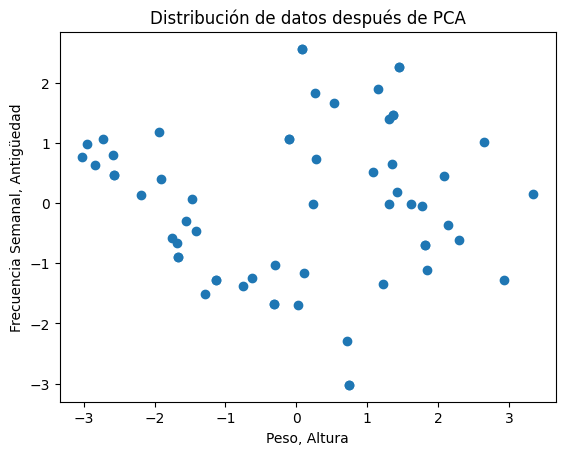

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Aplicar PCA con 2 componentes principales
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Visualización con etiquetas descriptivas basadas en la variabilidad capturada por PCA
plt.scatter(df_pca[:, 0], df_pca[:, 1])
plt.xlabel("Peso, Altura")
plt.ylabel("Frecuencia Semanal, Antigüedad")
plt.title("Distribución de datos después de PCA")
plt.show()


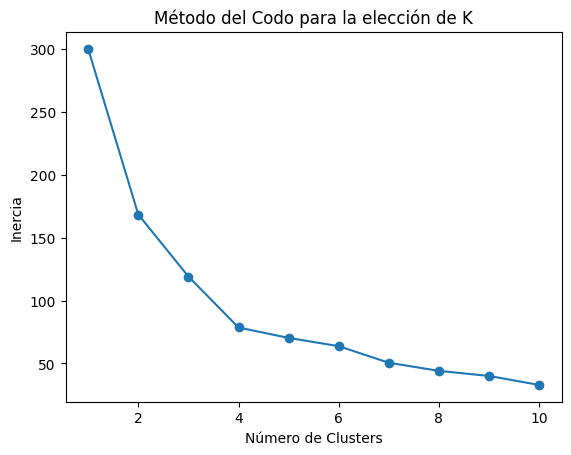

In [33]:
# Método del Codo para elegir número de clusters en K-Means
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo para la elección de K")
plt.show()

# Definir número óptimo de clusters según el método del codo
optimal_k = 3

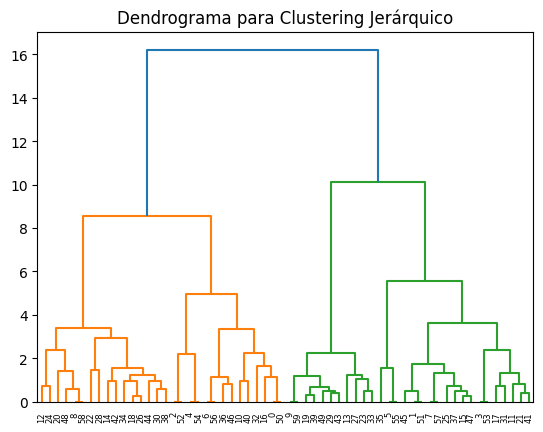

In [37]:
# Aplicación de Modelos de Clustering

# K-Means con el número óptimo de clusters obtenido por el método del codo
optimal_k = 3  # Ajustar según la gráfica del método del codo
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(df_scaled)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(df_scaled)

# Clustering Jerárquico
linkage_matrix = linkage(df_scaled, method='ward')
dendrogram(linkage_matrix)
plt.title("Dendrograma para Clustering Jerárquico")
plt.show()


In [39]:
from sklearn.cluster import AgglomerativeClustering

# Evaluación con Silhouette Score para K-Means y DBSCAN
silhouette_kmeans = silhouette_score(df_scaled, labels_kmeans)
silhouette_dbscan = silhouette_score(df_scaled, labels_dbscan) if len(set(labels_dbscan)) > 1 else -1

# Aplicación del clustering jerárquico con el número óptimo de clusters
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
labels_agg = agg_clustering.fit_predict(df_scaled)

# Cálculo del Silhouette Score para Clustering Jerárquico
silhouette_agg = silhouette_score(df_scaled, labels_agg)

# Mostrar resultados
print(f"Silhouette Score - K-Means: {silhouette_kmeans}")
print(f"Silhouette Score - DBSCAN: {silhouette_dbscan}")
print(f"Silhouette Score - Clustering Jerárquico: {silhouette_agg}")


Silhouette Score - K-Means: 0.3636302807987356
Silhouette Score - DBSCAN: 0.21354516357967887
Silhouette Score - Clustering Jerárquico: 0.3991686108391159


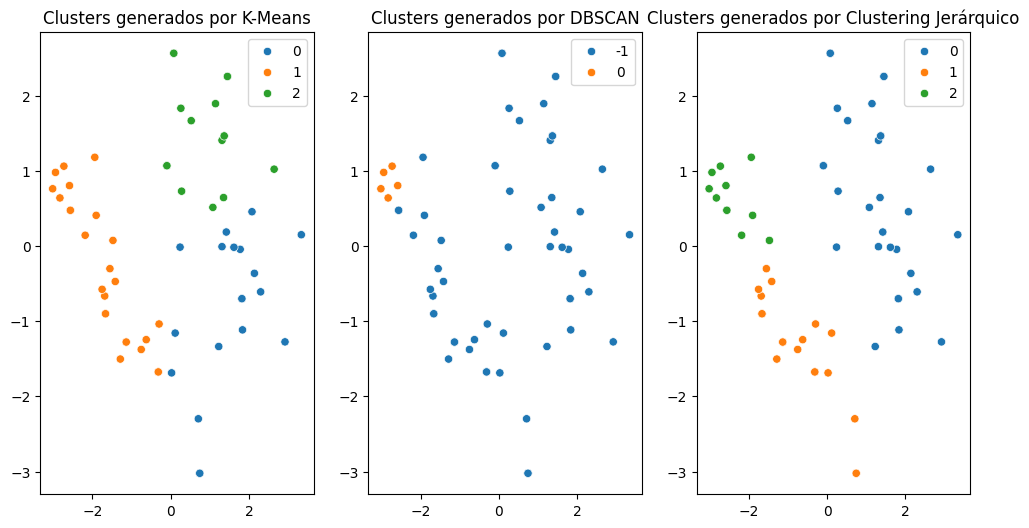

In [40]:
# Visualización de Resultados
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=labels_kmeans, palette="tab10")
plt.title("Clusters generados por K-Means")

plt.subplot(1, 3, 2)
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=labels_dbscan, palette="tab10")
plt.title("Clusters generados por DBSCAN")

plt.subplot(1, 3, 3)
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=labels_agg, palette="tab10")
plt.title("Clusters generados por Clustering Jerárquico")

plt.show()

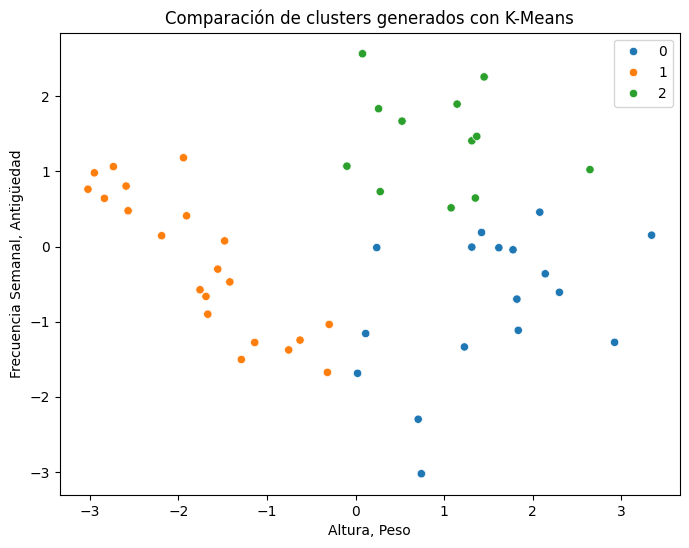

         FrecuenciaSemanal  Antiguedad
Cluster                               
0                 2.210526     12.0000
1                 4.200000      4.6400
2                 4.500000     14.4375


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización de clusters generados con K-Means, considerando las variables del dataset
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=labels_kmeans, palette="tab10")
plt.title("Comparación de clusters generados con K-Means")
plt.xlabel("Altura, Peso")  # Componente principal más influyente en la agrupación
plt.ylabel("Frecuencia Semanal, Antigüedad")  # Segunda variable con mayor impacto en PCA
plt.show()

# Evaluación de distribución de clusters en función de las variables más relevantes
df_clean['Cluster'] = labels_kmeans
print(df_clean.groupby("Cluster").mean()[["FrecuenciaSemanal", "Antiguedad"]])
